# 14 — Transformações, adequação e limites dos diagnósticos

Extensão exploratória informada pelas análises anteriores. Protocolo registrado antes dos novos testes no commit 1e598373ca0d9b2ec796a5d7b031be30da3fe188. O objetivo é investigar a adequação, sem fabricar significância ou garantir aprovação.

In [1]:
from pathlib import Path
import sys
ROOT=Path.cwd().parent if Path.cwd().name=='notebooks' else Path.cwd()
sys.path.insert(0,str(ROOT/'src'))
from adequacao_series import *
from IPython.display import display, Markdown
pd.set_option('display.max_columns',24)

## 1. O que muda nas séries

ΔI é a mudança mensal em pontos percentuais. 100Δlog(I) é a variação relativa aproximada em %. Δ12 compara cada mudança com a mudança do mesmo mês do ano anterior: modifica a pergunta e elimina observações. Não remove automaticamente autocorrelação; pode introduzir dependência de média móvel. As quatro transformações são comparadas em datas comuns, sem ranking de BIC entre escalas. Dummies são mantidas nas primeiras diferenças; a robustez sazonal usa intercepto. Não removemos permanentemente extremos.

In [2]:
display(pd.DataFrame([{'Transformação':k,'Log I':v[0],'Diferença sazonal':v[1],'Dummies mensais':not v[1]} for k,v in SPECS.items()]))

,Transformação,Log I,Diferença sazonal,Dummies mensais
0,Diferença simples,False,False,True
1,Variação relativa,True,False,True
2,Diferença sazonal,False,True,False
3,Relativa e sazonal,True,True,False


## 2. Dinâmica nacional: total, grupos, tipologias e indicadores

São 25 exposições × 2 períodos × 4 transformações, família fixa de 200 hipóteses. BIC escolhe lags próprios e cruzados em amostra comum; o teste conjunto é condicionado à seleção. O ótimo com q=0 é registrado separadamente. Preferir q=0 não constitui violação de pressupostos. Toda transformação é uma sensibilidade, não confirmação independente.

In [3]:
nacional=run_national()
display(nacional.groupby(['Período','Transformação']).agg(Planejados=('Exposição','size'),Estimáveis=('p','count'),Nominais=('p',lambda x:(x<.05).sum()),BH=('p BH',lambda x:(x<.05).sum()),Diagnósticos=('Diagnóstico favorável','sum'),Adequação_e_utilidade=('Adequação e utilidade','sum')).reset_index())

Nacional Total (2013–2024) Diferença simples
Nacional Total (2013–2024) Variação relativa
Nacional Total (2013–2024) Diferença sazonal
Nacional Total (2013–2024) Relativa e sazonal
Nacional Pré-pandemia (até jan/2020) Diferença simples
Nacional Pré-pandemia (até jan/2020) Variação relativa
Nacional Pré-pandemia (até jan/2020) Diferença sazonal
Nacional Pré-pandemia (até jan/2020) Relativa e sazonal


,Período,Transformação,Planejados,Estimáveis,Nominais,BH,Diagnósticos,Adequação_e_utilidade
0,Pré-pandemia (até jan/2020),Diferença sazonal,25,23,4,2,0,0
1,Pré-pandemia (até jan/2020),Diferença simples,25,23,6,2,0,0
2,Pré-pandemia (até jan/2020),Relativa e sazonal,25,23,4,0,0,0
3,Pré-pandemia (até jan/2020),Variação relativa,25,23,6,3,0,0
4,Total (2013–2024),Diferença sazonal,25,25,9,1,21,0
5,Total (2013–2024),Diferença simples,25,25,3,1,0,0
6,Total (2013–2024),Relativa e sazonal,25,25,8,1,20,0
7,Total (2013–2024),Variação relativa,25,25,4,1,0,0


/workspace/scratch/1b453e109626/tcc/src/segunda_etapa.py:100: FutureWarning: acorr_breusch_godfrey currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  r={'BG1 p':acorr_breusch_godfrey(model,nlags=1)[1],'BG12 p':acorr_breusch_godfrey(model,nlags=12)[1],'BP p':het_breuschpagan(model.resid,model.model.exog)[1],'ARCH3 p':het_arch(model.resid,nlags=3)[1],'CUSUM p':breaks_cusumolsresid(model.resid,ddof=len(model.params))[1],'RESET p':linear_reset(model,power=2,test_type='fitted',use_f=True,cov_type='HC3').pvalue,'ACF12':acf(model.resid,nlags=12,fft=False)[12],'Raiz própria':roots(model)}
/root/.local/lib/python3.12/site-packages/statsmodels/stats/diagnostic.py:997: FutureWarning: acorr_lm currently returns a plain tup

## 3. Diagnósticos item a item

ADF e KPSS têm hipóteses nulas diferentes. Concordância é uma triagem e p≥5% não prova adequação. BG avalia dependência residual; RESET avalia forma funcional, sem identificar a variável omitida; CUSUM informa instabilidade. Não rejeitar todos eles não prova causalidade nem exogeneidade. HAC não conserta uma equação mal especificada. Heterocedasticidade e influência são reportadas. ACF negativa forte após diferenciação merece cautela sobre sobrediferenciação.

,Período,Transformação,n efetivo,Estacionária I status,Estacionária D status,BG1 p,BG12 p,RESET p,CUSUM p,Raiz própria,q0 preferido,p,p BH,Motivos diagnósticos
0,Total (2013–2024),Diferença simples,119.0,Sem indicação de não estacionariedade,Sem indicação de não estacionariedade,0.081568,0.806478,0.011142,0.783643,0.881727,True,0.099336,0.315352,Forma da equação (RESET)
25,Total (2013–2024),Variação relativa,119.0,Sem indicação de não estacionariedade,Sem indicação de não estacionariedade,0.042201,0.619276,0.008111,0.701645,0.884663,True,0.195934,0.461020,Autocorrelação curta; Forma da equação (RESET)
50,Total (2013–2024),Diferença sazonal,119.0,Sem indicação de não estacionariedade,Sem indicação de não estacionariedade,0.795153,0.101349,0.587552,0.646246,0.964766,True,0.039265,0.185514,Sem indicação nos diagnósticos examinados
75,Total (2013–2024),Relativa e sazonal,119.0,Sem indicação de não estacionariedade,Sem indicação de não estacionariedade,0.984560,0.083471,0.447902,0.651506,0.966966,True,0.061496,0.244833,Sem indicação nos diagnósticos examinados
100,Pré-pandemia (até jan/2020),Diferença simples,60.0,Inconclusiva,Sem indicação de não estacionariedade,0.593584,0.146116,0.399135,0.402581,0.913774,True,0.388045,0.692938,Estacionariedade da inadimplência inconclusiva
125,Pré-pandemia (até jan/2020),Variação relativa,60.0,Inconclusiva,Sem indicação de não estacionariedade,0.451222,0.115260,0.302211,0.401216,0.911484,True,0.565267,0.807524,Estacionariedade da inadimplência inconclusiva
150,Pré-pandemia (até jan/2020),Diferença sazonal,60.0,Inconclusiva,Sem indicação de não estacionariedade,0.157968,0.335644,0.436606,0.194513,0.972252,True,0.096771,0.312165,Estacionariedade da inadimplência inconclusiva
175,Pré-pandemia (até jan/2020),Relativa e sazonal,60.0,Inconclusiva,Sem indicação de não estacionariedade,0.219339,0.307577,0.564487,0.222210,0.977114,True,0.102058,0.318931,Estacionariedade da inadimplência inconclusiva


,Período,Unidade,Exposição,Transformação,Família,Modelo,Unidade efeito,Série,ADF estatística,ADF p,ADF lag,ADF n,KPSS estatística,KPSS p,KPSS lag,KPSS limite,Estacionária,Avisos,Status,n transformado,Variância,ACF1,ACF12
0,Total (2013–2024),Brasil,Total nacional,Diferença simples,ADEQUACAO_NACIONAL,ADL BIC; datas comuns; I12,pontos percentuais de I,Inadimplência,-4.170541,7.387805e-04,6,136,0.161144,0.1,6,>=0.10,True,adfuller currently returns a plain tuple whose...,Sem indicação de não estacionariedade,143,0.009953,0.181417,0.322216
1,Total (2013–2024),Brasil,Total nacional,Diferença simples,ADEQUACAO_NACIONAL,ADL BIC; datas comuns; I12,pontos percentuais de I,Exposição,-8.947009,8.932137e-15,4,138,0.055823,0.1,14,>=0.10,True,adfuller currently returns a plain tuple whose...,Sem indicação de não estacionariedade,143,0.481355,-0.383328,0.291883
50,Total (2013–2024),Brasil,Total nacional,Variação relativa,ADEQUACAO_NACIONAL,ADL BIC; datas comuns; I12,variação logarítmica percentual de I,Inadimplência,-4.194926,6.720518e-04,6,136,0.130614,0.1,7,>=0.10,True,adfuller currently returns a plain tuple whose...,Sem indicação de não estacionariedade,143,6.922013,0.197637,0.325156
51,Total (2013–2024),Brasil,Total nacional,Variação relativa,ADEQUACAO_NACIONAL,ADL BIC; datas comuns; I12,variação logarítmica percentual de I,Exposição,-8.947009,8.932137e-15,4,138,0.055823,0.1,14,>=0.10,True,adfuller currently returns a plain tuple whose...,Sem indicação de não estacionariedade,143,0.481355,-0.383328,0.291883
100,Total (2013–2024),Brasil,Total nacional,Diferença sazonal,ADEQUACAO_NACIONAL,ADL BIC; datas comuns; I12,pontos percentuais de I,Inadimplência,-6.407622,1.925733e-08,0,130,0.086882,0.1,5,>=0.10,True,adfuller currently returns a plain tuple whose...,Sem indicação de não estacionariedade,131,0.013754,0.512978,-0.437597
101,Total (2013–2024),Brasil,Total nacional,Diferença sazonal,ADEQUACAO_NACIONAL,ADL BIC; datas comuns; I12,pontos percentuais de I,Exposição,-13.283191,7.619473e-25,1,129,0.328974,0.1,54,>=0.10,True,adfuller currently returns a plain tuple whose...,Sem indicação de não estacionariedade,131,0.650901,-0.292692,-0.273986
150,Total (2013–2024),Brasil,Total nacional,Relativa e sazonal,ADEQUACAO_NACIONAL,ADL BIC; datas comuns; I12,variação logarítmica percentual de I,Inadimplência,-6.143283,7.876630e-08,0,130,0.071390,0.1,5,>=0.10,True,adfuller currently returns a plain tuple whose...,Sem indicação de não estacionariedade,131,9.699932,0.543275,-0.452239
151,Total (2013–2024),Brasil,Total nacional,Relativa e sazonal,ADEQUACAO_NACIONAL,ADL BIC; datas comuns; I12,variação logarítmica percentual de I,Exposição,-13.283191,7.619473e-25,1,129,0.328974,0.1,54,>=0.10,True,adfuller currently returns a plain tuple whose...,Sem indicação de não estacionariedade,131,0.650901,-0.292692,-0.273986
200,Pré-pandemia (até jan/2020),Brasil,Total nacional,Diferença simples,ADEQUACAO_NACIONAL,ADL BIC; datas comuns; I12,pontos percentuais de I,Inadimplência,-1.970285,2.997520e-01,5,78,0.314327,0.1,0,>=0.10,False,adfuller currently returns a plain tuple whose...,Inconclusiva,84,0.007949,-0.097371,0.400372
201,Pré-pandemia (até jan/2020),Brasil,Total nacional,Diferença simples,ADEQUACAO_NACIONAL,ADL BIC; datas comuns; I12,pontos percentuais de I,Exposição,-11.287897,1.403189e-20,1,82,0.158992,0.1,25,>=0.10,True,adfuller currently returns a plain tuple whose...,Sem indicação de não estacionariedade,84,0.592234,-0.404781,0.260368


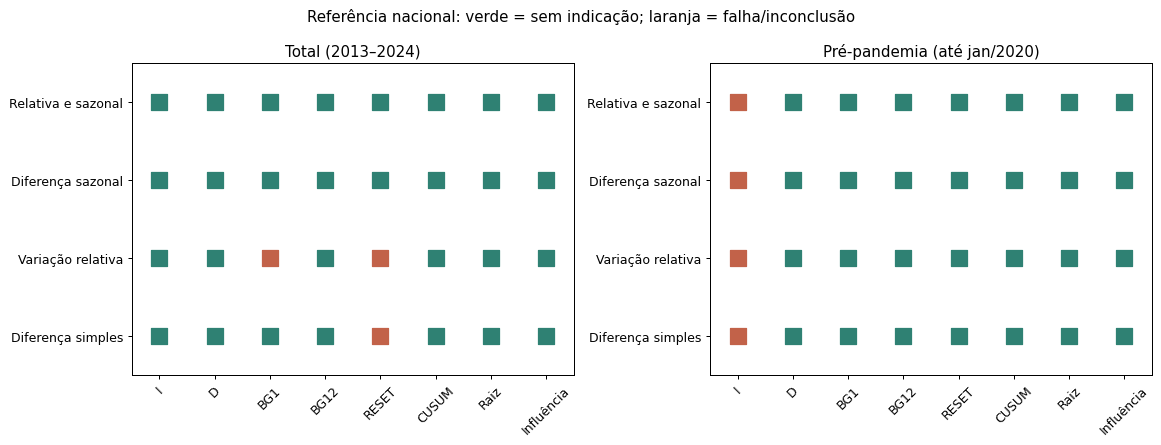

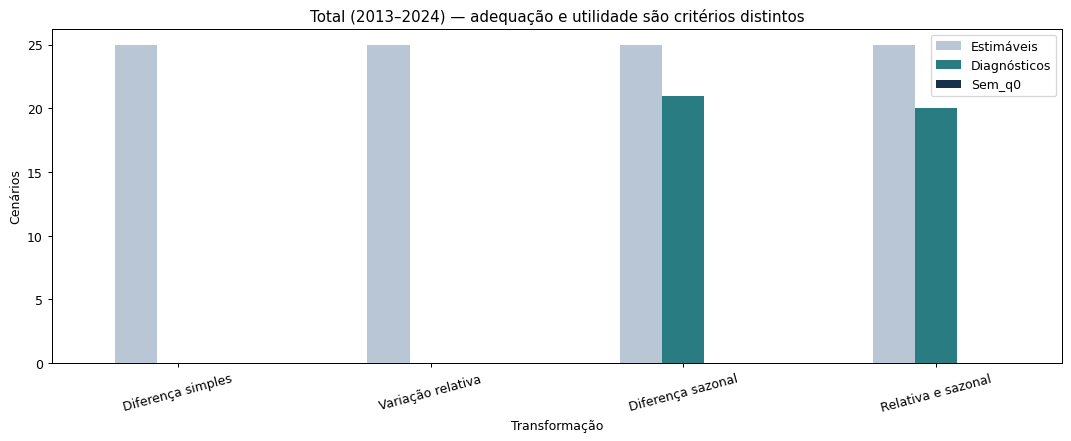

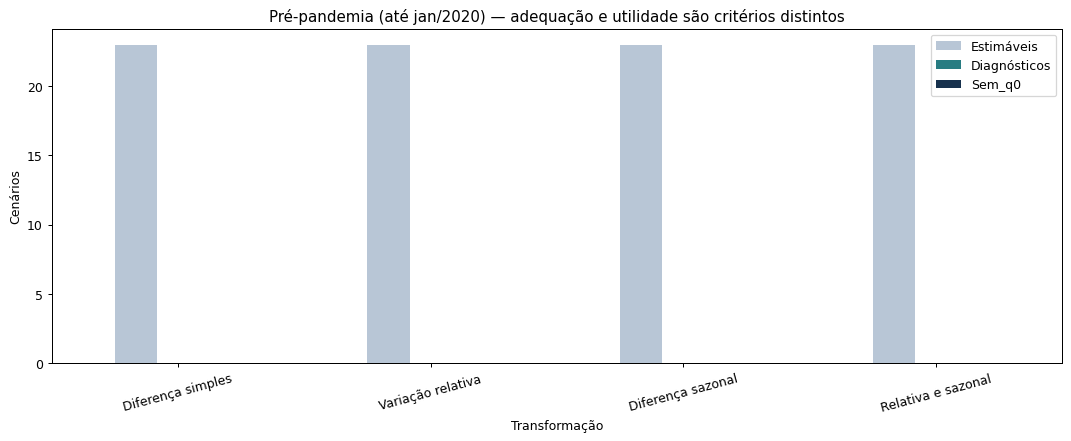

In [4]:
display(nacional[nacional.Exposição=='Total nacional'][['Período','Transformação','n efetivo','Estacionária I status','Estacionária D status','BG1 p','BG12 p','RESET p','CUSUM p','Raiz própria','q0 preferido','p','p BH','Motivos diagnósticos']])
display(pd.read_csv(AOUT/'estacionariedade.csv').query("Exposição == 'Total nacional'"))
figures()

## 4. UF × mês

Quatro medidas climáticas, quatro transformações e dois períodos: 32 hipóteses. Transformações e lags são computados dentro da UF; efeitos fixos UF e mês-calendário. DK não garante exogeneidade nem remove viés dinâmico. Os diagnósticos examinados são descritos separadamente dessas limitações, e não reaplicamos SPJ automaticamente. Modelos e saídas anteriores permanecem preservados.

In [5]:
painel=run_panel()
display(painel[['Período','Exposição','Transformação','Meses efetivos','Proporção UF estacionária I','Proporção UF estacionária D','Autocorrelação p DK','p','p BH','Diagnóstico favorável','Motivos diagnósticos']])

Painel Total (2013–2024) Diferença simples
Painel Total (2013–2024) Variação relativa
Painel Total (2013–2024) Diferença sazonal
Painel Total (2013–2024) Relativa e sazonal
Painel Pré-pandemia (até jan/2020) Diferença simples
Painel Pré-pandemia (até jan/2020) Variação relativa
Painel Pré-pandemia (até jan/2020) Diferença sazonal
Painel Pré-pandemia (até jan/2020) Relativa e sazonal


,Período,Exposição,Transformação,Meses efetivos,Proporção UF estacionária I,Proporção UF estacionária D,Autocorrelação p DK,p,p BH,Diagnóstico favorável,Motivos diagnósticos
0,Total (2013–2024),Clima | Protocolos,Diferença simples,119,0.851852,0.925926,2.115083e-02,0.867986,0.948019,False,Autocorrelação residual
1,Total (2013–2024),Clima | Municípios,Diferença simples,119,0.851852,0.851852,2.104587e-02,0.908413,0.948019,False,Autocorrelação residual
2,Total (2013–2024),Clima | Deslocamento,Diferença simples,119,0.851852,0.888889,2.064110e-02,0.329511,0.787302,False,Autocorrelação residual
3,Total (2013–2024),Clima | Habitações,Diferença simples,119,0.851852,0.925926,1.676577e-02,0.074760,0.458272,False,Autocorrelação residual
4,Total (2013–2024),Clima | Protocolos,Variação relativa,119,0.888889,0.925926,1.082649e-04,0.697124,0.821876,False,Autocorrelação residual; Influência material d...
5,Total (2013–2024),Clima | Municípios,Variação relativa,119,0.888889,0.851852,1.061181e-04,0.708708,0.821876,False,Autocorrelação residual; Influência material d...
6,Total (2013–2024),Clima | Deslocamento,Variação relativa,119,0.888889,0.888889,9.412619e-05,0.144395,0.460697,False,Autocorrelação residual
7,Total (2013–2024),Clima | Habitações,Variação relativa,119,0.888889,0.925926,8.525037e-05,0.100247,0.458272,False,Autocorrelação residual
8,Total (2013–2024),Clima | Protocolos,Diferença sazonal,119,1.000000,0.962963,1.129375e-02,0.695225,0.821876,False,Autocorrelação residual
9,Total (2013–2024),Clima | Municípios,Diferença sazonal,119,1.000000,0.925926,1.132471e-02,0.719142,0.821876,False,Autocorrelação residual


## 5. Resultados ajustados e adequação

Mostrar todos os resultados após BH, mesmo os reprovados na triagem; não filtrar antes de corrigir. Ausência de rejeição não prova ausência de efeito. Unidades de coeficientes mudam com o desfecho: diferenças relativas não são pontos percentuais. IC são pontuais e não incorporam seleção.

In [6]:
display(nacional[nacional['p BH']<.05][['Período','Exposição','Transformação','p','p BH','Soma coeficientes','IC baixo','IC alto','Diagnóstico favorável','q0 preferido','Motivos diagnósticos']])
display(painel[painel['p BH']<.05])
display(nacional[nacional['Diagnóstico favorável']==True][['Período','Exposição','Transformação','p','p BH','q0 preferido']])

,Período,Exposição,Transformação,p,p BH,Soma coeficientes,IC baixo,IC alto,Diagnóstico favorável,q0 preferido,Motivos diagnósticos
20,Total (2013–2024),Tipologia | Vendavais e Ciclones,Diferença simples,1.552658e-04,0.006645,-0.028250,-0.041085,-0.015416,False,True,Forma da equação (RESET)
45,Total (2013–2024),Tipologia | Vendavais e Ciclones,Variação relativa,1.661250e-04,0.006645,-0.746961,-1.089102,-0.404820,False,True,Forma da equação (RESET)
66,Total (2013–2024),Tipologia | Onda de Frio,Diferença sazonal,2.175706e-03,0.039558,0.013698,0.005046,0.022351,True,True,Sem indicação nos diagnósticos examinados
80,Total (2013–2024),Tipologia | Alagamentos,Relativa e sazonal,1.063461e-03,0.026587,0.710670,0.152379,1.268960,False,True,Estacionariedade da exposição inconclusiva
104,Pré-pandemia (até jan/2020),Grupo | Outros,Diferença simples,3.902138e-07,0.000057,-0.007767,-0.038602,0.023068,False,True,Estacionariedade da inadimplência inconclusiva
120,Pré-pandemia (até jan/2020),Tipologia | Vendavais e Ciclones,Diferença simples,1.274766e-04,0.006645,-0.036386,-0.065167,-0.007606,False,True,Estacionariedade da inadimplência inconclusiva
129,Pré-pandemia (até jan/2020),Grupo | Outros,Variação relativa,5.743288e-07,0.000057,-0.326071,-1.074073,0.421930,False,True,Estacionariedade da inadimplência inconclusiva
145,Pré-pandemia (até jan/2020),Tipologia | Vendavais e Ciclones,Variação relativa,2.271862e-04,0.007573,-0.860072,-1.587718,-0.132427,False,True,Estacionariedade da inadimplência inconclusiva
149,Pré-pandemia (até jan/2020),Clima | Habitações,Variação relativa,1.758831e-03,0.035177,-0.324197,-0.520175,-0.128219,False,False,Estacionariedade da inadimplência inconclusiva
151,Pré-pandemia (até jan/2020),Grupo | Climatológico,Diferença sazonal,1.412943e-03,0.031399,0.020513,0.008293,0.032733,False,False,Estacionariedade da inadimplência inconclusiva


,Período,Unidade,Exposição,Transformação,Família,Modelo,Unidade efeito,n efetivo,Meses efetivos,Início amostra,Fim amostra,Proporção UF estacionária I,...,IC alto,F DK,p,p DK6,p cluster UF,Diagnóstico favorável,Motivos diagnósticos,Limitação,Família n,p BH,p BY,p Holm


,Período,Exposição,Transformação,p,p BH,q0 preferido
50,Total (2013–2024),Total nacional,Diferença sazonal,0.039265,0.185514,True
51,Total (2013–2024),Grupo | Climatológico,Diferença sazonal,0.026409,0.160057,True
52,Total (2013–2024),Grupo | Hidrológico,Diferença sazonal,0.006164,0.056330,True
53,Total (2013–2024),Grupo | Meteorológico,Diferença sazonal,0.046877,0.213079,True
56,Total (2013–2024),Tipologia | Chuvas Intensas,Diferença sazonal,0.005084,0.056330,True
57,Total (2013–2024),Tipologia | Doenças infecciosas,Diferença sazonal,0.239010,0.503179,True
58,Total (2013–2024),Tipologia | Enxurradas,Diferença sazonal,0.797358,0.966494,True
59,Total (2013–2024),Tipologia | Erosão,Diferença sazonal,0.424866,0.711106,True
60,Total (2013–2024),Tipologia | Estiagem e Seca,Diferença sazonal,0.083976,0.289573,True
61,Total (2013–2024),Tipologia | Granizo,Diferença sazonal,0.116691,0.328707,True


## 6. Verificação e checkpoint

Famílias, amostras comparáveis e ausência de features contemporâneas são conferidas. O notebook incorpora resultados executados. As projeções locais, previsão e TY anteriores não foram reestimados: esta extensão investiga transformação, não inventa uma nova identificação causal.

In [7]:
display(check())
checkpoint_new()
summary={'nacional_BH':int((nacional['p BH']<.05).sum()),'nacional_diagnosticos':int(nacional['Diagnóstico favorável'].sum()),'nacional_BH_e_diagnosticos':int(((nacional['p BH']<.05)&nacional['Diagnóstico favorável']).sum()),'painel_BH':int((painel['p BH']<.05).sum()),'painel_diagnosticos':int(painel['Diagnóstico favorável'].sum())}
display(Markdown('**Resumo executado:** '+str(summary)))

,Verificação,Status
0,200 hipóteses nacionais preservadas,passou
1,32 hipóteses painel preservadas,passou
2,BH Nacional,passou
3,Família Nacional,passou
4,BH Painel,passou
5,Família Painel,passou
6,Amostra comum entre candidatos,passou
7,Datas iguais entre transformações nacionais,passou
8,Datas iguais entre transformações painel,passou
9,Sem variável contemporânea Diferença simples,passou


**Resumo executado:** {'nacional_BH': 11, 'nacional_diagnosticos': 41, 'nacional_BH_e_diagnosticos': 1, 'painel_BH': 0, 'painel_diagnosticos': 0}